# Voting Classifier

<!-- **Objective: Learn how to apply the decision trees.** -->

** Learning Objectives **

By completing this exercise, you should be able to:

 - Apply ensemble methods to solve a real-world prediction problem.

 - Implement and compare Random Forest, Bagging, AdaBoost, and hard and soft voting classifiers.

- Evaluate, compare, and refine model performance using systematic tuning.

**Source: Lantz Brett, Machine Learning with R. Packt Publishing**

# I. Collecting data

The idea behind our credit model is to identify factors that are predictive of higher risk of default.

We will use a Data available in a dataset donated to the UCI Machine Learning Data Repository by Hans Hofmann of the University of Hamburg.

The dataset contains information on loans obtained from a credit agency in Germany.

The credit dataset includes 1,000 examples on loans, plus a set of numeric and nominal features indicating the characteristics of the loan and the loan applicant.

A class variable indicates whether the loan went into default.


# II. Exploring and preparing the data

## A. Exploring the data

Let’s import the data. The data is available on Canvas, named **credit.csv**.

**1. Import and read the csv data file.**

**2. Examine the structure of the data frame.**

**3.  Which features can be a possible predictor of a default loan?**

**4. How can you check and study those features? Explain.**

**5.  What percentage of the loans in the dataset went into default? is it high? How this result can aﬀect the loaning bank?**

## B. Data preparation

**6.Convert categorical data into numerical.**

**7. Check if your dataset is randomized.**

# III. Training a model on the data

**8. Split the data into training and testing sets.**

**9. Apply the decision tree algorithm.**

**10. Visualize the model after training**

**11. Find the best predictor features.**

# IV. Evaluating model performance

**12. Check the accuracy of the model. Check other metrics.**

**13. Is this model a good model?**

# V. Improving model performance

**14. How can you improve the performance of your decision tree model?**

**15. Apply different ways of improve the model. Discuss and explain your results.**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
# 1. Import and read the csv data file
try:
    df = pd.read_csv('./credit.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: credit.csv not found. Please upload the file.")

Dataset loaded successfully.


In [10]:
# 2. Examine the structure
print("\n--- Data Structure ---")
print(df.info())
print("\n--- First 5 Rows ---")
df.head()


--- Data Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone          

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [11]:
# 3 & 4. Studying Features
print("\n--- Numerical Statistics ---")
df.describe()


--- Numerical Statistics ---


,months_loan_duration,amount,percent_of_income,years_at_residence,age,existing_loans_count,dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


3. Which features can be a possible predictor of a default loan?
- The most significant predictors are typically Checking Account Status, Credit History, Loan Duration, and Employment Length. These features are strong indicators because they represent an applicant's current liquid assets, past reliability in debt repayment, the timeframe of financial risk, and overall income stability.

4. How can you check and study those features? Explain?
- I can study them using Descriptive Statistics (like means and counts) to understand the data distribution and Data Visualization (such as histograms, box plots, and correlation matrices). Visualizing the data helps identify patterns, outliers, and relationships between the features and the loan default status.

In [12]:
# Define the features to study
features_to_study = ['checking_balance', 'credit_history', 'months_loan_duration', 'employment_duration']

# 4.1. Statistical Summary
print("--- Statistical Summary of Key Features ---")
# For numerical features like loan duration
print(df['months_loan_duration'].describe())

# For categorical features, check the frequency of each category
for col in ['checking_balance', 'credit_history', 'employment_duration']:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

--- Statistical Summary of Key Features ---
count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: months_loan_duration, dtype: float64

Value counts for checking_balance:
checking_balance
unknown       394
< 0 DM        274
1 - 200 DM    269
> 200 DM       63
Name: count, dtype: int64

Value counts for credit_history:
credit_history
good         530
critical     293
poor          88
very good     49
perfect       40
Name: count, dtype: int64

Value counts for employment_duration:
employment_duration
1 - 4 years    339
> 7 years      253
4 - 7 years    174
< 1 year       172
unemployed      62
Name: count, dtype: int64


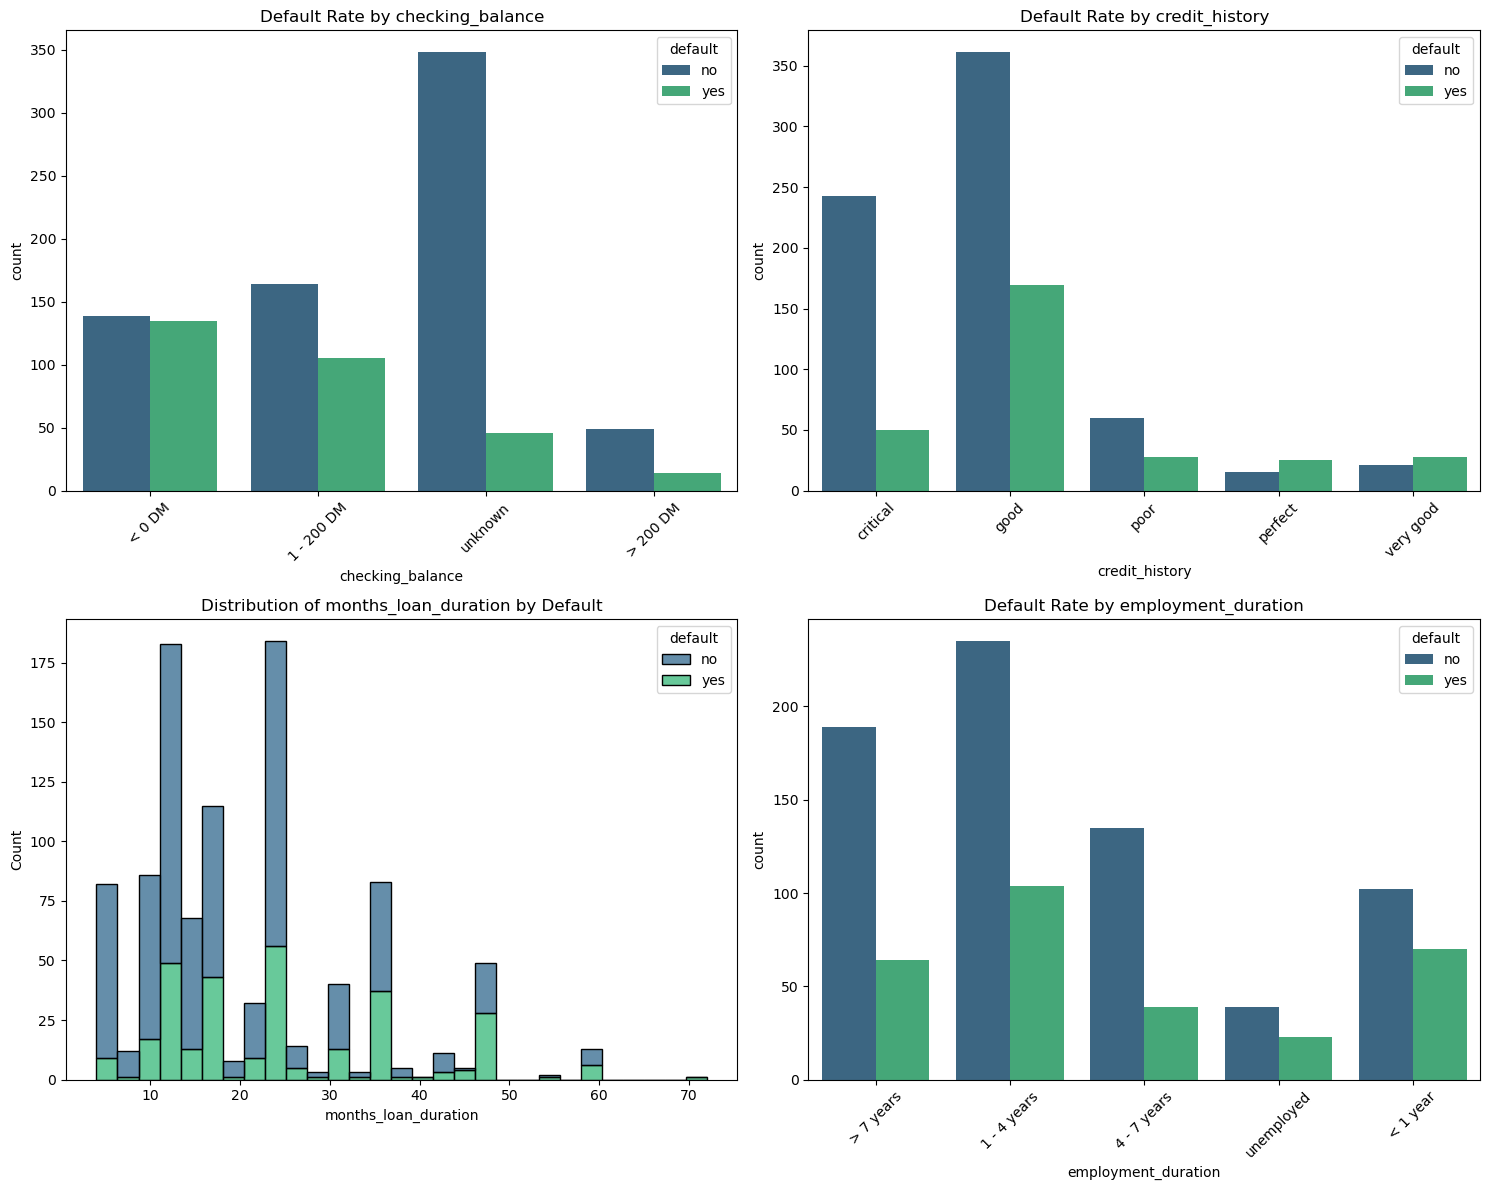

In [13]:
# 4.2. Visualization: Relationship with Default
# Setting up the figure for plots
plt.figure(figsize=(15, 12))

for i, col in enumerate(features_to_study, 1):
    plt.subplot(2, 2, i)
    if col == 'months_loan_duration':
        # Histogram for numerical data
        sns.histplot(data=df, x=col, hue='default', multiple="stack", palette='viridis')
        plt.title(f'Distribution of {col} by Default')
    else:
        # Count plot for categorical data
        sns.countplot(data=df, x=col, hue='default', palette='viridis')
        plt.title(f'Default Rate by {col}')
        plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('feature_analysis.png')
plt.show()

In [14]:
# 4.3. Cross-tabulation (Percentage of default per category)
print("\n--- Default Rate by Feature Category ---")
for col in ['checking_balance', 'credit_history', 'employment_duration']:
    # Calculate percentage of default within each category
    analysis = pd.crosstab(df[col], df['default'], normalize='index') * 100
    print(f"\nPercentage for {col}:")
    print(analysis)


--- Default Rate by Feature Category ---

Percentage for checking_balance:
default                  no        yes
checking_balance                      
1 - 200 DM        60.966543  39.033457
< 0 DM            50.729927  49.270073
> 200 DM          77.777778  22.222222
unknown           88.324873  11.675127

Percentage for credit_history:
default                no        yes
credit_history                      
critical        82.935154  17.064846
good            68.113208  31.886792
perfect         37.500000  62.500000
poor            68.181818  31.818182
very good       42.857143  57.142857

Percentage for employment_duration:
default                     no        yes
employment_duration                      
1 - 4 years          69.321534  30.678466
4 - 7 years          77.586207  22.413793
< 1 year             59.302326  40.697674
> 7 years            74.703557  25.296443
unemployed           62.903226  37.096774


In [15]:
# 5. Percentage of defaults
default_counts = df['default'].value_counts(normalize=True) * 100

print(f"Percentage of loans: \n{default_counts}")

# Extract the specific value for 'yes'
default_pct = default_counts['yes']
print(f"\nThe percentage of loans that went into default is: {default_pct}%")

Percentage of loans: 
default
no     70.0
yes    30.0
Name: proportion, dtype: float64

The percentage of loans that went into default is: 30.0%


5. What percentage of the loans in the dataset went into default? is it high? How this result can aﬀect the loaning bank?
- 30% of the loans in the dataset went into default.
- This is considered very high, as typical bank default rates are usually below $5\%$. Such a high rate can lead to significant financial losses, reduced profitability, and a need for the bank to increase its capital reserves to cover potential risks.

In [16]:
# 6. Convert categorical data into numerical
# One-Hot Encoding
# We use drop_first=True to avoid the dummy variable trap
df_clean = pd.get_dummies(df, drop_first=True)
print("\n--- Data shape after encoding ---")
print(df_clean.shape)


--- Data shape after encoding ---
(1000, 36)


In [17]:
# 7. Check if randomized (Shuffle the data)
# We shuffle to remove any sorting bias (example: dataset sorted by Date or ID)
# NOTE: for bank datasetm it is sorted by date -> we have to randomize it
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

In [18]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   months_loan_duration             1000 non-null   int64
 1   amount                           1000 non-null   int64
 2   percent_of_income                1000 non-null   int64
 3   years_at_residence               1000 non-null   int64
 4   age                              1000 non-null   int64
 5   existing_loans_count             1000 non-null   int64
 6   dependents                       1000 non-null   int64
 7   checking_balance_< 0 DM          1000 non-null   bool 
 8   checking_balance_> 200 DM        1000 non-null   bool 
 9   checking_balance_unknown         1000 non-null   bool 
 10  credit_history_good              1000 non-null   bool 
 11  credit_history_perfect           1000 non-null   bool 
 12  credit_history_poor              1000 non-null   

In [19]:
# 8. Split the data
target_col = 'default_yes'

X = df_clean.drop(target_col, axis=1) # features
y = df_clean[target_col]              # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV

In [21]:
dt_base = DecisionTreeClassifier(random_state=42)

In [22]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]})

In [23]:
bag_param_grid = {
    'estimator__max_depth': [None, 10, 20],
    'estimator__min_samples_leaf': [1, 5],
    'n_estimators': [50, 100],
    'max_samples': [0.8, 1.0]
}

bag_grid = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42), 
    bag_param_grid, cv=5, n_jobs=-1
)
bag_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=BaggingClassifier(estimator=DecisionTreeClassifier(),
                                         random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [None, 10, 20],
                         'estimator__min_samples_leaf': [1, 5],
                         'max_samples': [0.8, 1.0], 'n_estimators': [50, 100]})

In [24]:
ada_param_grid = {
    'estimator__max_depth': [1, 2, 3],
    'estimator__criterion': ['gini', 'entropy'],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=42), 
    ada_param_grid, cv=5, n_jobs=-1
)
ada_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(),
                                          random_state=42),
             n_jobs=-1,
             param_grid={'estimator__criterion': ['gini', 'entropy'],
                         'estimator__max_depth': [1, 2, 3],
                         'learning_rate': [0.01, 0.1, 1.0],
                         'n_estimators': [50, 100, 200]})

In [25]:
best_rf = rf_grid.best_estimator_
best_bag = bag_grid.best_estimator_
best_ada = ada_grid.best_estimator_

In [26]:
estimators = [('rf', best_rf), ('bag', best_bag), ('ada', best_ada)]

voting_hard = VotingClassifier(estimators=estimators, voting='hard')
voting_soft = VotingClassifier(estimators=estimators, voting='soft')

voting_hard.fit(X_train, y_train)
voting_soft.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(criterion='entropy',
                                                     min_samples_leaf=2,
                                                     random_state=42)),
                             ('bag',
                              BaggingClassifier(estimator=DecisionTreeClassifier(),
                                                max_samples=0.8,
                                                n_estimators=50,
                                                random_state=42)),
                             ('ada',
                              AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                                                 n_estimators=100,
                                                 random_state=42))],
                 voting='soft')

In [27]:
models = {
    "Random Forest": rf_grid,
    "Bagging": bag_grid,
    "AdaBoost": ada_grid,
    "Voting (Hard)": voting_hard,
    "Voting (Soft)": voting_soft
}

print(f"{'Model':<20} | {'Test Accuracy':<15}")
print("-" * 40)

for name, model in models.items():
    acc = model.score(X_test, y_test)
    print(f"{name:<20} | {acc:<15.4f}")

print("\nBest RF Params:", rf_grid.best_params_)
print("Best Bagging Params:", bag_grid.best_params_)
print("Best AdaBoost Params:", ada_grid.best_params_)

Model                | Test Accuracy  
----------------------------------------
Random Forest        | 0.7133         
Bagging              | 0.7233         
AdaBoost             | 0.7400         
Voting (Hard)        | 0.7333         
Voting (Soft)        | 0.7433         

Best RF Params: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best Bagging Params: {'estimator__max_depth': None, 'estimator__min_samples_leaf': 1, 'max_samples': 0.8, 'n_estimators': 50}
Best AdaBoost Params: {'estimator__criterion': 'gini', 'estimator__max_depth': 2, 'learning_rate': 1.0, 'n_estimators': 100}


In [28]:
from sklearn.metrics import classification_report

models = {
    "Random Forest": rf_grid,
    "Bagging": bag_grid,
    "AdaBoost": ada_grid,
    "Voting (Hard)": voting_hard,
    "Voting (Soft)": voting_soft
}

print(f"{'Model':<20} | {'Test Accuracy':<15}")
print("-" * 40)

for name, model in models.items():
    acc = model.score(X_test, y_test)
    print(f"{name:<20} | {acc:<15.4f}")

print("\nBest RF Params:", rf_grid.best_params_)
print("Best Bagging Params:", bag_grid.best_params_)
print("Best AdaBoost Params:", ada_grid.best_params_)

print("\n" + "=" * 60)
print("Classification Reports")
print("=" * 60)

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("-" * len(name))
    print(classification_report(y_test, y_pred))

Model                | Test Accuracy  
----------------------------------------
Random Forest        | 0.7133         
Bagging              | 0.7233         
AdaBoost             | 0.7400         
Voting (Hard)        | 0.7333         
Voting (Soft)        | 0.7433         

Best RF Params: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best Bagging Params: {'estimator__max_depth': None, 'estimator__min_samples_leaf': 1, 'max_samples': 0.8, 'n_estimators': 50}
Best AdaBoost Params: {'estimator__criterion': 'gini', 'estimator__max_depth': 2, 'learning_rate': 1.0, 'n_estimators': 100}

Classification Reports

Random Forest
-------------
              precision    recall  f1-score   support

       False       0.74      0.88      0.81       203
        True       0.59      0.36      0.45        97

    accuracy                           0.71       300
   macro avg       0.67      0.62      0.63       

# Part 2

1. Model Training and Evaluation Discoveries

- During model training and evaluation, I compared several ensemble methods, including Random Forest, Bagging, AdaBoost, and two Voting classifiers (hard and soft). Overall, all ensemble models performed reasonably well and consistently outperformed a single base estimator. Among the individual ensemble methods, Random Forest and Bagging produced the strongest and most stable results, while AdaBoost showed slightly more variability depending on its hyperparameters. The voting classifiers benefited from combining multiple models and achieved competitive performance compared to the best individual model.

2. Impact of Systematic Tuning

- After hyperparameter tuning using grid search, the performance of Random Forest, Bagging, and AdaBoost improved compared to their default configurations. In particular, tuning parameters such as the number of estimators and model complexity helped reduce overfitting and improved generalization on the test set. The improvement was most noticeable for Random Forest and AdaBoost, where the tuned models achieved higher and more balanced precision and recall across classes, not just higher accuracy.

3. Key Insights and Lessons Learned

- A key insight from this experiment is that accuracy alone is not sufficient to evaluate model quality. By examining the classification reports, I observed differences in precision, recall, and F1-score between classes, even when overall accuracy was similar. Another important lesson is that ensemble methods are robust, but their performance still depends strongly on proper tuning. A practical challenge was selecting appropriate hyperparameter ranges and managing the increased computational cost of grid search. Overall, the experiment demonstrates that model tuning and ensemble learning significantly improve predictive performance and produce more reliable classifiers.